In [31]:
import numpy as np

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *


from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators

import neuromancer.psl as psl

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


### Load Dynamics Model

In [4]:
import torch
import torch.nn as nn

import torch

run_id = 1
models_dir = f"../results/models/dynamics/run_{run_id}/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/sindy.pt", map_location=device)

# Rebuild library and model skeleton
lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
sindy = SINDyVectorized(
    library=lib,
    n_out=ckpt["model_cfg"]["n_out"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
sindy.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(sindy.active_idx):
    sindy.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
sindy._plan = sindy._recompile_fast_path(device=device)

# Load weights
sindy.load_state_dict(ckpt["state_dict"], strict=True)


/var/folders/7d/4w2xzdbj279fj424x2h2w2xh0000gn/T/ipykernel_45398/41613913.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(models_dir) + "/sindy.pt"

<All keys matched successfully>

### Load trained Policy

In [351]:
import torch
import torch.nn as nn


import torch

run_id = 1
models_dir = f"../results/models/run_{run_id}/SparseDPC/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/policy_sparse.pt", map_location=device)

# Rebuild library and model skeleton
policy_lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
policy_sparse = SINDyVectorized(
    library=policy_lib,
    n_out=ckpt["model_cfg"]["n_out"],
    policy_name=ckpt["model_cfg"]["policy_name"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
policy_sparse.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(policy_sparse.active_idx):
    policy_sparse.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
policy_sparse._plan = policy_sparse._recompile_fast_path(device=device)

# Load weights
policy_sparse.load_state_dict(ckpt["state_dict"], strict=True)


/var/folders/7d/4w2xzdbj279fj424x2h2w2xh0000gn/T/ipykernel_45398/1839147410.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(models_dir) + "/policy_

<All keys matched successfully>

In [352]:
policy_sparse.pretty_print()

u0 = -3.6897e-01·x0 + -1.1302e-01·x1 + -6.6236e-02·x0*r0 + +2.4151e-01·sin(1·x0) + +2.9072e-02·sin(2·x0) + -1.4231e-01·sin(1·x1) + -5.1272e-02·cos(2·x0) + -1.7473e-01·sin(1·r0) + -2.1855e-02·sin(2·r0) + +1.8451e-01·cos(1·r0) + +6.3838e-02·cos(2·r0)
u1 = +8.9680e-02·x0 + -1.6469e-01·x1 + -8.2952e-02·r0 + +1.6717e-01·r1 + +2.3780e-02·x0*x1 + +2.5266e-02·r0*r1 + -5.1539e-02·x0*r1 + +4.0326e-02·sin(1·x1) + -4.7810e-02·sin(1·r1)


In [353]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x0 + +1.0000e+00·u0
dx1/dt = +1.0000e+00·x1 + +1.0000e+00·u1


### Create a nominal and noisy system

In [362]:
import copy
noisy_policy_sparse = copy.deepcopy(policy_sparse)


In [363]:
ellipse_configs = {"p": 3,
                   "b": 1,
                   "c": 0.0,
                   "d": 0.0,
                   "theta": 0.0}

xmin = -5.
xmax = 5.
umin = -1.0
umax = 1.0


A_noisy = torch.tensor([[1.0, -0.2],
                         [0.0, 1.0]], dtype=torch.float32, device=device)
B_noisy = torch.tensor([[1.2, 0.0],
                         [0.0, 0.8]], dtype=torch.float32, device=device)

def noisy_system (x,u):
    x_next =  x @A_noisy.T + u @ B_noisy.T
    return x_next

# Ground truth system model
ts = 1.0

# Problem dimensions
nx = 2     # number of states
nu = 2      # number of control inputs
nref = 2


def make_square(center, length):
    """
    Build a rectangle ((x1,y1),(x2,y2)) from center and side length.
    center: (cx, cy)
    length: full side length
    """
    cx, cy = center
    half = length / 2.0
    return ((cx - half, cy - half), (cx + half, cy + half))

side = 3
init_center = (3, -3)
init_rect = make_square(init_center, side)

# reference region center)
ref_center = (-3,3)
ref_rect = make_square(ref_center, side)




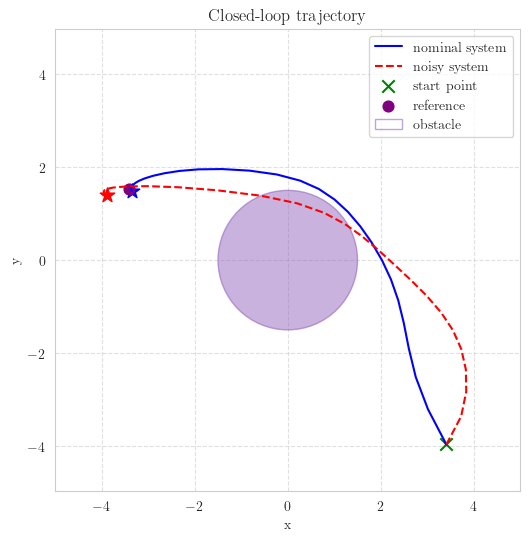

In [364]:
# Closed-loop simulation setup
nsteps = 50


data = make_test_sample_discrete(
    nx=nx, nsteps=nsteps, seed= 0
    , device=device,
    ellipse= ellipse_configs,
    init_rect= init_rect,
    ref_rect= ref_rect,
)

gt_integrator_node = Node(sindy, ['xn', 'u'], ['xn'], name='model')

gt_integrator_node_noisy = Node(noisy_system, ['xn', 'u'], ['xn'], name='model')

policy_node = Node(
            lambda xn,r : torch.clamp(policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node_noisy]))

# Simulate system
gt_sindy_policy_system.nsteps = nsteps
gt_sindy_policy_system_noisy.nsteps = nsteps

trajectories = gt_sindy_policy_system(data)
trajectories_noisy = gt_sindy_policy_system_noisy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

traj_x_noisy = trajectories_noisy["xn"]
traj_u_noisy = trajectories_noisy["u"]
traj_r_noisy = trajectories_noisy['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "nominal system", "color": "blue"},
        {"traj": traj_x_noisy,   "label": "noisy system",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


#### Make functions to compute the gradients for policy

In [365]:
import torch

def compute_updates(dyn_model, policy_sparse, x, ref, u, *, use_coupling=True):
    params = tuple(policy_sparse.Xi)
    for p in policy_sparse.Xi:
        assert p.requires_grad

    F_vec = dyn_model(x, u).squeeze(0)       # (nx,)
    nx = F_vec.numel()
    e = (ref - x).mean(0)                    # (nx,)

    # rows of ∂F_i/∂a_k
    g_rows = []
    for i in range(nx):
        gi = torch.autograd.grad(F_vec[i], params, retain_graph=True, create_graph=False, allow_unused=False)
        g_rows.append(gi)

    if use_coupling and nx >= 4:
        x_req = x.detach().requires_grad_(True)

        def F_x_fixed(x_var):
            # keep batch dimension to keep jacobian shapes saner
            return dyn_model(x_var, u)       # (1, nx)

        J_x = torch.autograd.functional.jacobian(F_x_fixed, x_req, vectorize=True)
        # Normalize to (nx, nx) robustly
        J_x = J_x.squeeze()                  # drop singleton dims
        if J_x.dim() != 2:
            J_x = J_x.reshape(nx, nx)

        # Apply your coupling: 0←1 and 2←3
        alpha01 = J_x[0, 1]
        g_rows[0] = tuple(g * alpha01 for g in g_rows[1])
        alpha23 = J_x[2, 3]
        g_rows[2] = tuple(g * alpha23 for g in g_rows[3])

    # denom = 1 + ||J_a||_F^2
    fro2 = F_vec.new_zeros(())
    for i in range(nx):
        for g in g_rows[i]:
            fro2 = fro2 + (g**2).sum()
    denom = 1.0 + fro2

    # updates_k = (Σ_i e_i * ∂F_i/∂a_k) / denom
    updates = []
    for k, _p in enumerate(policy_sparse.Xi):
        num_k = sum(e[i] * g_rows[i][k] for i in range(nx))
        updates.append(num_k / denom)

    return updates


import torch

def apply_policy_updates(policy_sparse, updates, gamma=1.0, clip=None):
    """
    Add updates to policy_sparse.Xi parameters:
      Xi_k <- Xi_k + gamma * updates[k]

    Args:
        policy_sparse: object with attribute `Xi` (e.g., nn.ParameterList of coef tensors)
        updates: list[Tensor], same structure/shapes as policy_sparse.Xi
        gamma: scalar step size
        clip: optional float for elementwise clipping of the update
    """
    assert len(updates) == len(policy_sparse.Xi), "updates and Xi must align"

    with torch.no_grad():
        for Xi_k, dk in zip(policy_sparse.Xi, updates):
            # ensure dtype/device match
            dk = dk.to(dtype=Xi_k.dtype, device=Xi_k.device)
            # guard against NaN/Inf
            dk = torch.nan_to_num(dk, nan=0.0, posinf=0.0, neginf=0.0)
            # optional clipping
            if clip is not None:
                dk = dk.clamp(min=-clip, max=clip)
            # in-place coefficient update
            Xi_k.add_(gamma * dk)


In [366]:
pol_configs = {
    "l1_coef": 0.0002,
    "Q_con_obs": 2000.0,
    "Q_con_x": 10.0,
    "Q_con_u": 10.0,
    "Q_u": 0.02,
    "Q_r": 1.0,
    "Q_dx": 0.0,
    "Q_du": 0.0001,
    "lr": 0.002,
    "epochs": 10000,
    "threshold": 0.08,
    "prune_every": 2000,
    "prune_every_min": 300,
    "prune_every_decay": 200,
    "change_prune_every": True,
    "threshold_mult": 1.3,
    "threshold_max" : 0.12,
    "prune_noise": 0.01,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9,
}

x  = variable('xn')
x1 = x[:, :, [0]]
x2 = x[:, :, [1]]

p = ellipse_configs["p"]
b = ellipse_configs["b"]
c = ellipse_configs["c"]
d = ellipse_configs["d"]

obstacle_pen = pol_configs["Q_con_obs"] * (((p/2)**2 < (b*(x1 - c)**2 + (x2 - d)**2)) ^ 2)
obstacle_pen.update_name("obstacle_pen")

In [373]:
# Build lists for dynamics and policies (extend these if you have >2)
noisy_policy_sparse = copy.deepcopy(policy_sparse)
noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node_noisy]))

x_trajectory_unconst = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory_unconst = torch.zeros([1,1,2])
gamma = 0.005
error_hist = []
f_hist = []

for t in range(1, len(data['r'][0])):

    x = x_trajectory_unconst[:, -1, :].detach()
    r = data['r'][:, len(x_trajectory_unconst[0]), :].detach()
    u = noisy_policy_sparse(x,r)

    # Compute grads for the reference tracking only
    policy_grads = compute_updates(
        dyn_model=sindy,
        policy_sparse=noisy_policy_sparse,
        x=x, ref=r,
        u=u
    )

    # # Apply the updates
    apply_policy_updates(noisy_policy_sparse, policy_grads, gamma=gamma, clip=1.0)

    gt_sindy_policy_system_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_system_noisy({
        'xn': x_trajectory_unconst[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory_unconst[0]), :].unsqueeze(0)
    })

    # Log trajectories
    x_trajectory_unconst = torch.cat([x_trajectory_unconst, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory_unconst = torch.cat([u_trajectory_unconst, next_step_data['u'].detach()[:,  -1:, :]], dim=1)


In [374]:
# Build lists for dynamics and policies (extend these if you have >2)
noisy_policy_sparse = copy.deepcopy(policy_sparse)
noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node_noisy]))

x_trajectory_const = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory_const = torch.zeros([1,1,2])
gamma = 0.003
error_hist = []
f_hist = []
N = 5

for t in range(1, len(data['r'][0])):
    x = x_trajectory_const[:, -1, :].detach()
    r = data['r'][:, len(x_trajectory_const[0]), :].detach()
    u = noisy_policy_sparse(x,r)

    # Compute grads for the obstacle avoidance:

    gt_sindy_policy_system_noisy.nsteps = N
    sys_out = gt_sindy_policy_system_noisy({
        'xn': x_trajectory_const[:, -1, :].unsqueeze(0),
        'r' : r.unsqueeze(0).expand(1, N, -1)  # (B,T,2)
    })

    # --- Evaluate obstacle_pen on the rollout (returns dict, still connected to graph) ---
    out = obstacle_pen(sys_out)
    weighted = out["obstacle_pen"]
    for pol in noisy_policy_sparse.Xi:
        if pol.grad is not None:
            pol.grad.zero_()
    weighted.backward()
    policy_grads_obs = []
    for pol in noisy_policy_sparse.Xi:
        policy_grads_obs.append(-1. * pol.grad)

    u = noisy_policy_sparse(x,r)
    # Compute grads for the reference tracking only
    policy_grads_ref = compute_updates(
        dyn_model=sindy,
        policy_sparse=noisy_policy_sparse,
        x=x, ref=r,
        u=u
    )

    #print(f"Timestep: {t}, obstacle grads: {policy_grads_obs}, ref_grads: {policy_grads_ref}")
    policy_grads = [a + b for a, b in zip(policy_grads_obs, policy_grads_ref)]

    # # Apply the updates
    apply_policy_updates(noisy_policy_sparse, policy_grads, gamma=0.05 if weighted==0 else gamma, clip=1.0)

    gt_sindy_policy_system_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_system_noisy({
        'xn': x_trajectory_const[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory_const[0]), :].unsqueeze(0)
    })

    # Log trajectories
    x_trajectory_const = torch.cat([x_trajectory_const, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory_const = torch.cat([u_trajectory_const, next_step_data['u'].detach()[:,  -1:, :]], dim=1)


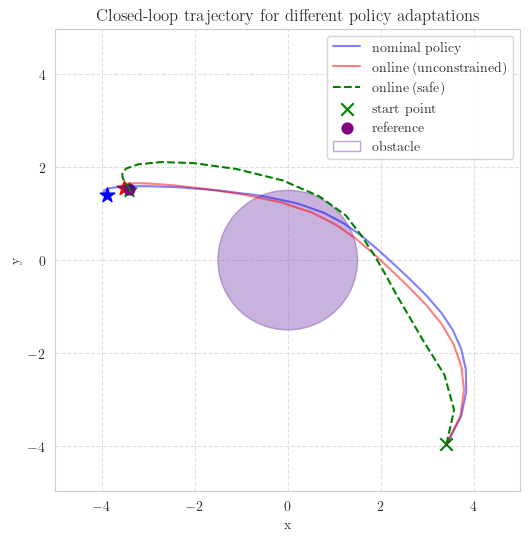

In [375]:
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x_noisy, "label": "nominal policy", "color": "blue", "alpha": 0.5},
        {"traj": x_trajectory_unconst,   "label": "online (unconstrained)",   "color": "red", "linestyle": "-", "alpha": 0.5},
        {"traj": x_trajectory_const,   "label": "online (safe)",   "color": "green", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    theta=ellipse_configs["theta"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory for different policy adaptations"
)


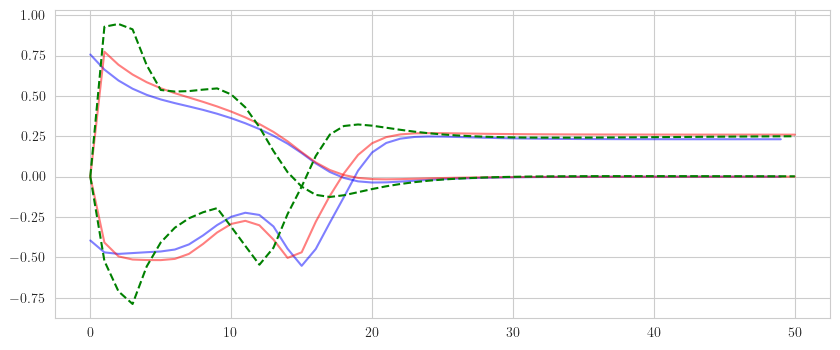

In [382]:
u_traj_list=[
        {"traj": traj_u_noisy, "label": "nominal policy", "color": "blue", "alpha": 0.5},
        {"traj": u_trajectory_unconst,   "label": "online (unconstrained)",   "color": "red", "linestyle": "-", "alpha": 0.5},
        {"traj": u_trajectory_const,   "label": "online (safe)",   "color": "green", "linestyle": "--"}
    ]
plt.figure(figsize=(10,4))
for cfg in u_traj_list:
    U = cfg["traj"]
    if isinstance(U, torch.Tensor):
        U = U.detach().cpu().numpy()
    U = U[0]  # (T, nx)

    u0, u1 = U[:, 0], U[:, 1]
    color     = cfg.get("color", None)
    linestyle = cfg.get("linestyle", "-")
    alpha     = cfg.get("alpha", 1.0)
    label     = cfg.get("label", "trajectory")

    plt.plot(u0, lw=1.5, color=color, linestyle=linestyle,
            alpha=alpha, label=label)
    plt.plot(u1, lw=1.5, color=color, linestyle=linestyle,
            alpha=alpha, label=label)

In [341]:
traj[0]["traj"]

tensor([[[ 3.4109, -3.9648],
         [ 3.0038, -3.1648],
         [ 2.6154, -2.3648],
         [ 2.3628, -1.5648],
         [ 2.0829, -0.8018],
         [ 1.7001, -0.1211],
         [ 1.2203,  0.4844],
         [ 0.6262,  1.0078],
         [-0.1315,  1.4339],
         [-1.0326,  1.7436],
         [-1.8102,  1.9257],
         [-2.2993,  2.0032],
         [-2.5813,  2.0191],
         [-2.7282,  2.0042],
         [-2.7938,  1.9775],
         [-2.8164,  1.9494],
         [-2.8189,  1.9244],
         [-2.8132,  1.9038],
         [-2.8050,  1.8875],
         [-2.7969,  1.8751],
         [-2.7899,  1.8657],
         [-2.7841,  1.8588],
         [-2.7796,  1.8537],
         [-2.7761,  1.8499],
         [-2.7735,  1.8472],
         [-2.7715,  1.8452],
         [-2.7701,  1.8438],
         [-2.7690,  1.8428],
         [-2.7683,  1.8420],
         [-2.7677,  1.8415],
         [-2.7673,  1.8411],
         [-2.7670,  1.8409],
         [-2.7668,  1.8407],
         [-2.7667,  1.8405],
         [-2.7